## **GPU Accelerated Notebook**
To run this notebook efficiently for 100k+ rows:
**Google Colab:**
1. Navigate to **Runtime > Change runtime type**
2. Select **T4 GPU** under Hardware accelerator and click Save.

**Kaggle:**
1. In notebook edit mode, expand the **Notebook Options** panel on the right.
2. Select **GPU T4x2** (or P100) under Accelerator.

The notebook uses `XGBRegressor` on GPU natively for faster training. Linear Regression and Random Forest stay on CPU (though RF could be updated to `cuRF`, XGBoost is usually more powerful).


# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor as RFR_sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import warnings, itertools
warnings.simplefilter(action='ignore')

# 2. Data Loading

In [2]:
# Install Kaggle API client
!pip install -q kaggle

# Make a directory for Kaggle and move the kaggle.json file there
# You need to upload your kaggle.json file to Colab's file browser first.
# Go to the left sidebar, click the 'Files' icon, then 'Upload to session storage'.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset from Kaggle
!kaggle datasets download -d mohankrishnathalla/medical-insurance-cost-prediction -p /content

# Unzip the downloaded file
!unzip -o /content/medical-insurance-cost-prediction.zip -d /content

# Load the data into a pandas DataFrame from the local path
data = pd.read_csv('/content/medical_insurance.csv')

# Drop 'person_id' column if it exists
if "person_id" in data.columns:
    data.drop(columns=["person_id"], inplace=True)

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction
License(s): CC0-1.0
100% 5.62M/5.62M [00:00<00:00, 44.9MB/s]

Archive:  /content/medical-insurance-cost-prediction.zip
  inflating: /content/medical_insurance.csv  


In [3]:
data.head()

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,...,0,1,0,1,0,2,0,1,0,0
1,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,...,0,1,1,0,0,1,0,1,1,0
2,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,...,0,0,1,1,0,2,1,0,1,0
3,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,...,0,0,0,1,0,0,1,0,0,0
4,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,...,0,1,0,2,0,1,1,0,1,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   sex                          100000 non-null  object 
 2   region                       100000 non-null  object 
 3   urban_rural                  100000 non-null  object 
 4   income                       100000 non-null  float64
 5   education                    100000 non-null  object 
 6   marital_status               100000 non-null  object 
 7   employment_status            100000 non-null  object 
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  object 
 12  alcohol_freq                 69917 non-null   object 
 13  

In [5]:
data.shape

(100000, 53)

## 2.1 Handling Missing Values

In [6]:
# Check missing values
print("Missing values per column:")
print(data.isnull().sum()[data.isnull().sum() > 0])
print(f"\nTotal rows with missing values: {data.isnull().any(axis=1).sum()}")

# Fill missing alcohol_freq with 'Unknown'
data['alcohol_freq'] = data['alcohol_freq'].fillna('Unknown')
print(f"\nalcohol_freq missing after fill: {data['alcohol_freq'].isnull().sum()}")

Missing values per column:
alcohol_freq    30083
dtype: int64

Total rows with missing values: 30083

alcohol_freq missing after fill: 0


# 3. Exploratory Data Analysis (EDA)

## 3.1 Descriptive Statistics

In [7]:
data.describe()

,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,117.808970,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,15.369187,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,61.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,107.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,117.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,128.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,183.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


## 3.2 Target Variable Distribution (Before Cleaning)

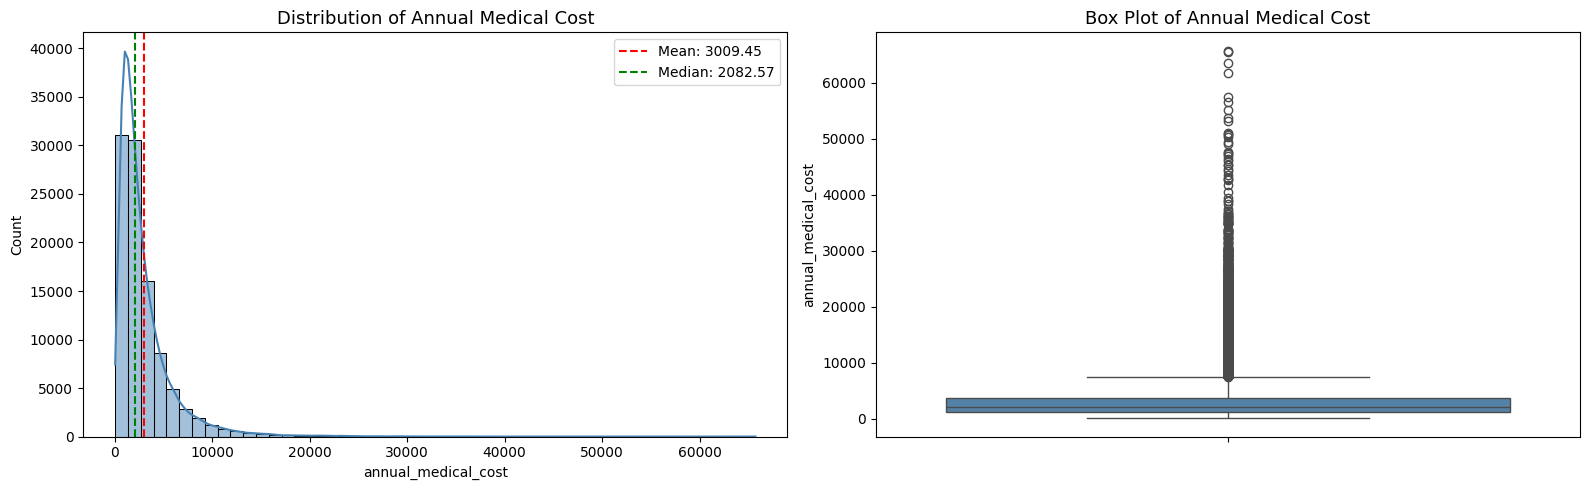

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data['annual_medical_cost'], kde=True, bins=50, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Annual Medical Cost', fontsize=13)
axes[0].axvline(data['annual_medical_cost'].mean(), color='red', linestyle='--', label=f"Mean: {data['annual_medical_cost'].mean():.2f}")
axes[0].axvline(data['annual_medical_cost'].median(), color='green', linestyle='--', label=f"Median: {data['annual_medical_cost'].median():.2f}")
axes[0].legend()

sns.boxplot(y=data['annual_medical_cost'], color='steelblue', ax=axes[1])
axes[1].set_title('Box Plot of Annual Medical Cost', fontsize=13)

plt.tight_layout()
plt.show()

## 3.3 Annual Medical Cost by Key Categories

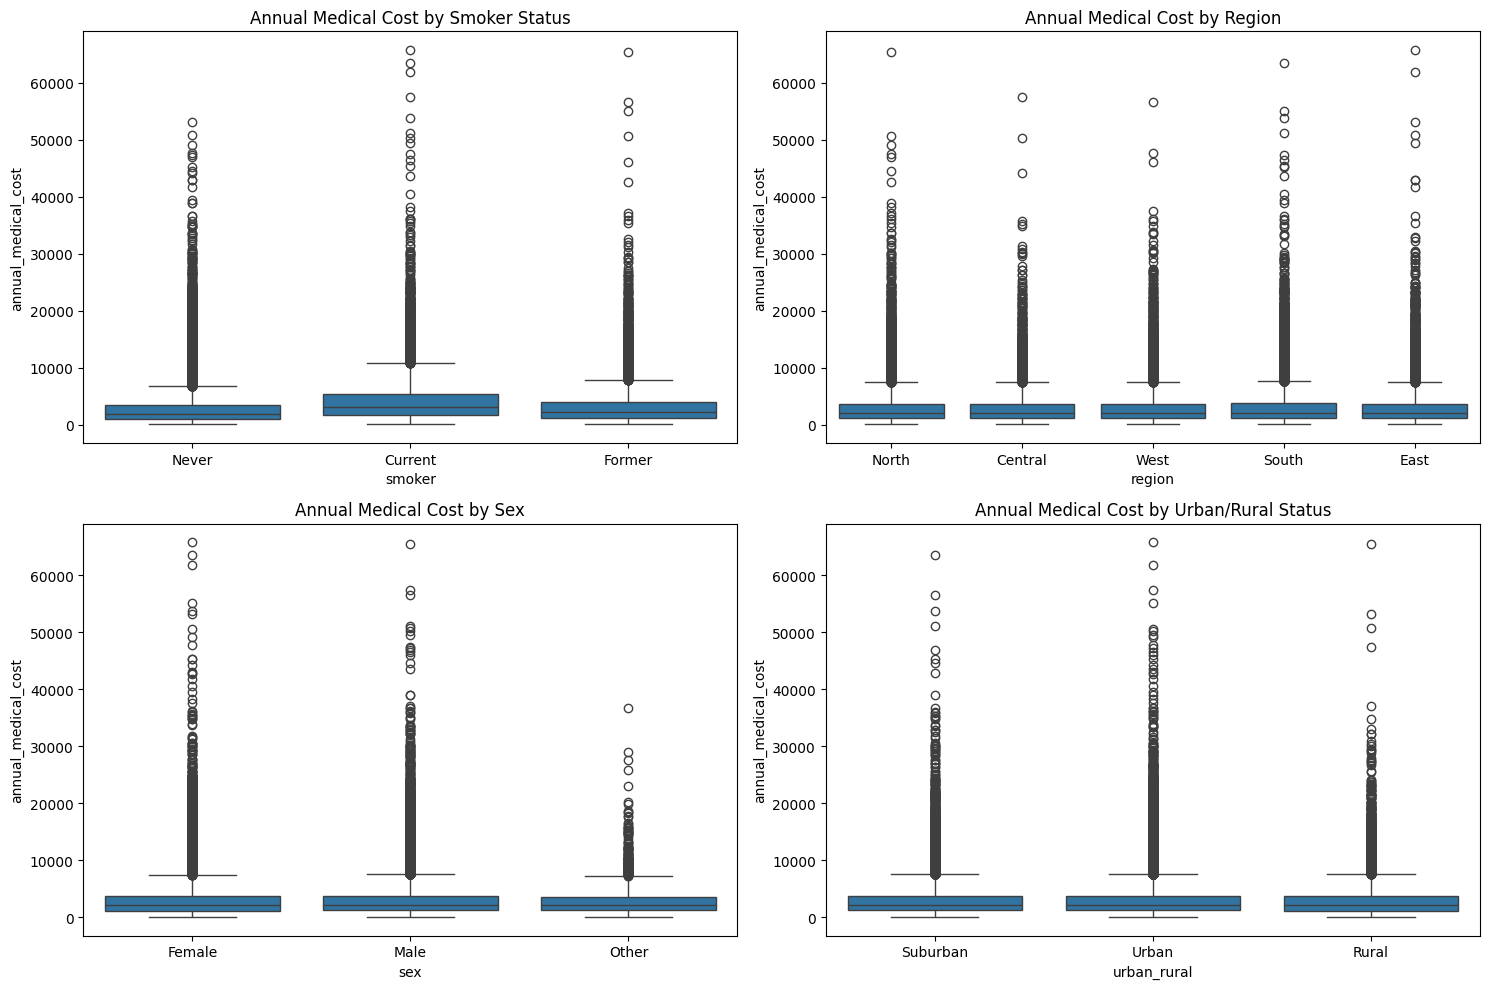

In [9]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='smoker', y='annual_medical_cost', data=data)
plt.title('Annual Medical Cost by Smoker Status')

plt.subplot(2, 2, 2)
sns.boxplot(x='region', y='annual_medical_cost', data=data)
plt.title('Annual Medical Cost by Region')

plt.subplot(2, 2, 3)
sns.boxplot(x='sex', y='annual_medical_cost', data=data)
plt.title('Annual Medical Cost by Sex')

plt.subplot(2, 2, 4)
sns.boxplot(x='urban_rural', y='annual_medical_cost', data=data)
plt.title('Annual Medical Cost by Urban/Rural Status')

plt.tight_layout()
plt.show()

## 3.4 Statistical Test: Smoker vs Non-Smoker

In [10]:
from scipy import stats

# Separate data into smoker and non-smoker groups
smokers = data[data['smoker'] == 'Yes']['annual_medical_cost']
non_smokers = data[data['smoker'] == 'No']['annual_medical_cost']

# Perform independent t-test
# We assume unequal variances (Welch's t-test) as a safer default,
# especially if sample sizes or variances might differ.
t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in annual medical costs between smokers and non-smokers.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in annual medical costs between smokers and non-smokers.")

T-statistic: nan
P-value: nan

Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in annual medical costs between smokers and non-smokers.


# 4. Outlier Detection & Removal

In [11]:
print(f"Median annual_medical_cost: {data['annual_medical_cost'].median():.2f}")
print(f"Mean annual_medical_cost:   {data['annual_medical_cost'].mean():.2f}")

Median annual_medical_cost: 2082.57
Mean annual_medical_cost:   3009.45


In [12]:
# Remove outliers using z-score method (threshold = 3)
data_cleaned = data[np.abs(stats.zscore(data['annual_medical_cost'])) < 3]

rows_removed = len(data) - len(data_cleaned)
print(f"Rows before:   {len(data):,}")
print(f"Rows after:    {len(data_cleaned):,}")
print(f"Rows removed:  {rows_removed:,} ({rows_removed/len(data)*100:.1f}%)")

Rows before:   100,000
Rows after:    98,124
Rows removed:  1,876 (1.9%)


## 4.1 Before vs After Outlier Removal

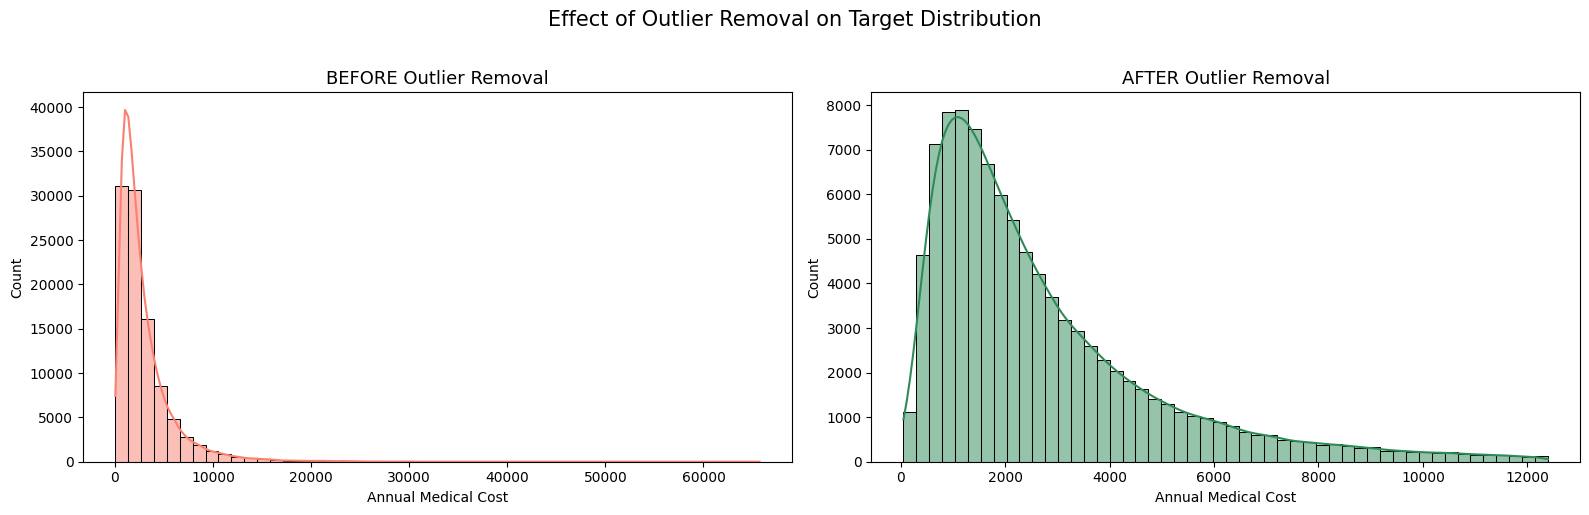

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data['annual_medical_cost'], kde=True, bins=50, color='salmon', ax=axes[0])
axes[0].set_title('BEFORE Outlier Removal', fontsize=13)
axes[0].set_xlabel('Annual Medical Cost')

sns.histplot(data_cleaned['annual_medical_cost'], kde=True, bins=50, color='seagreen', ax=axes[1])
axes[1].set_title('AFTER Outlier Removal', fontsize=13)
axes[1].set_xlabel('Annual Medical Cost')

plt.suptitle('Effect of Outlier Removal on Target Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
data_cleaned.describe()

,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,98124.000000,9.812400e+04,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,...,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000
mean,47.415128,4.987491e+04,2.430364,0.898292,26.984623,1.906679,0.088877,0.349007,1.228772,117.690045,...,0.014207,0.106253,0.127400,0.505992,0.156557,0.506054,0.507582,0.506502,0.361033,0.165872
std,15.967755,4.680422e+04,1.074857,0.950702,4.996617,1.715525,0.296323,1.315841,1.204456,15.325002,...,0.118342,0.308163,0.333422,0.746536,0.458026,0.743101,0.750266,0.746995,0.480303,0.371967
min,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,61.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.000000,0.000000,0.000000,0.000000,107.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,47.000000,3.620000e+04,2.000000,1.000000,27.000000,2.000000,0.000000,0.000000,1.000000,117.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.000000,0.000000,0.000000,2.000000,128.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.000000,3.000000,21.000000,11.000000,183.000000,...,1.000000,1.000000,1.000000,7.000000,5.000000,7.000000,7.000000,7.000000,1.000000,1.000000


# 5. Post-Cleaning Visualizations

## 5.1 Numeric Feature Distributions

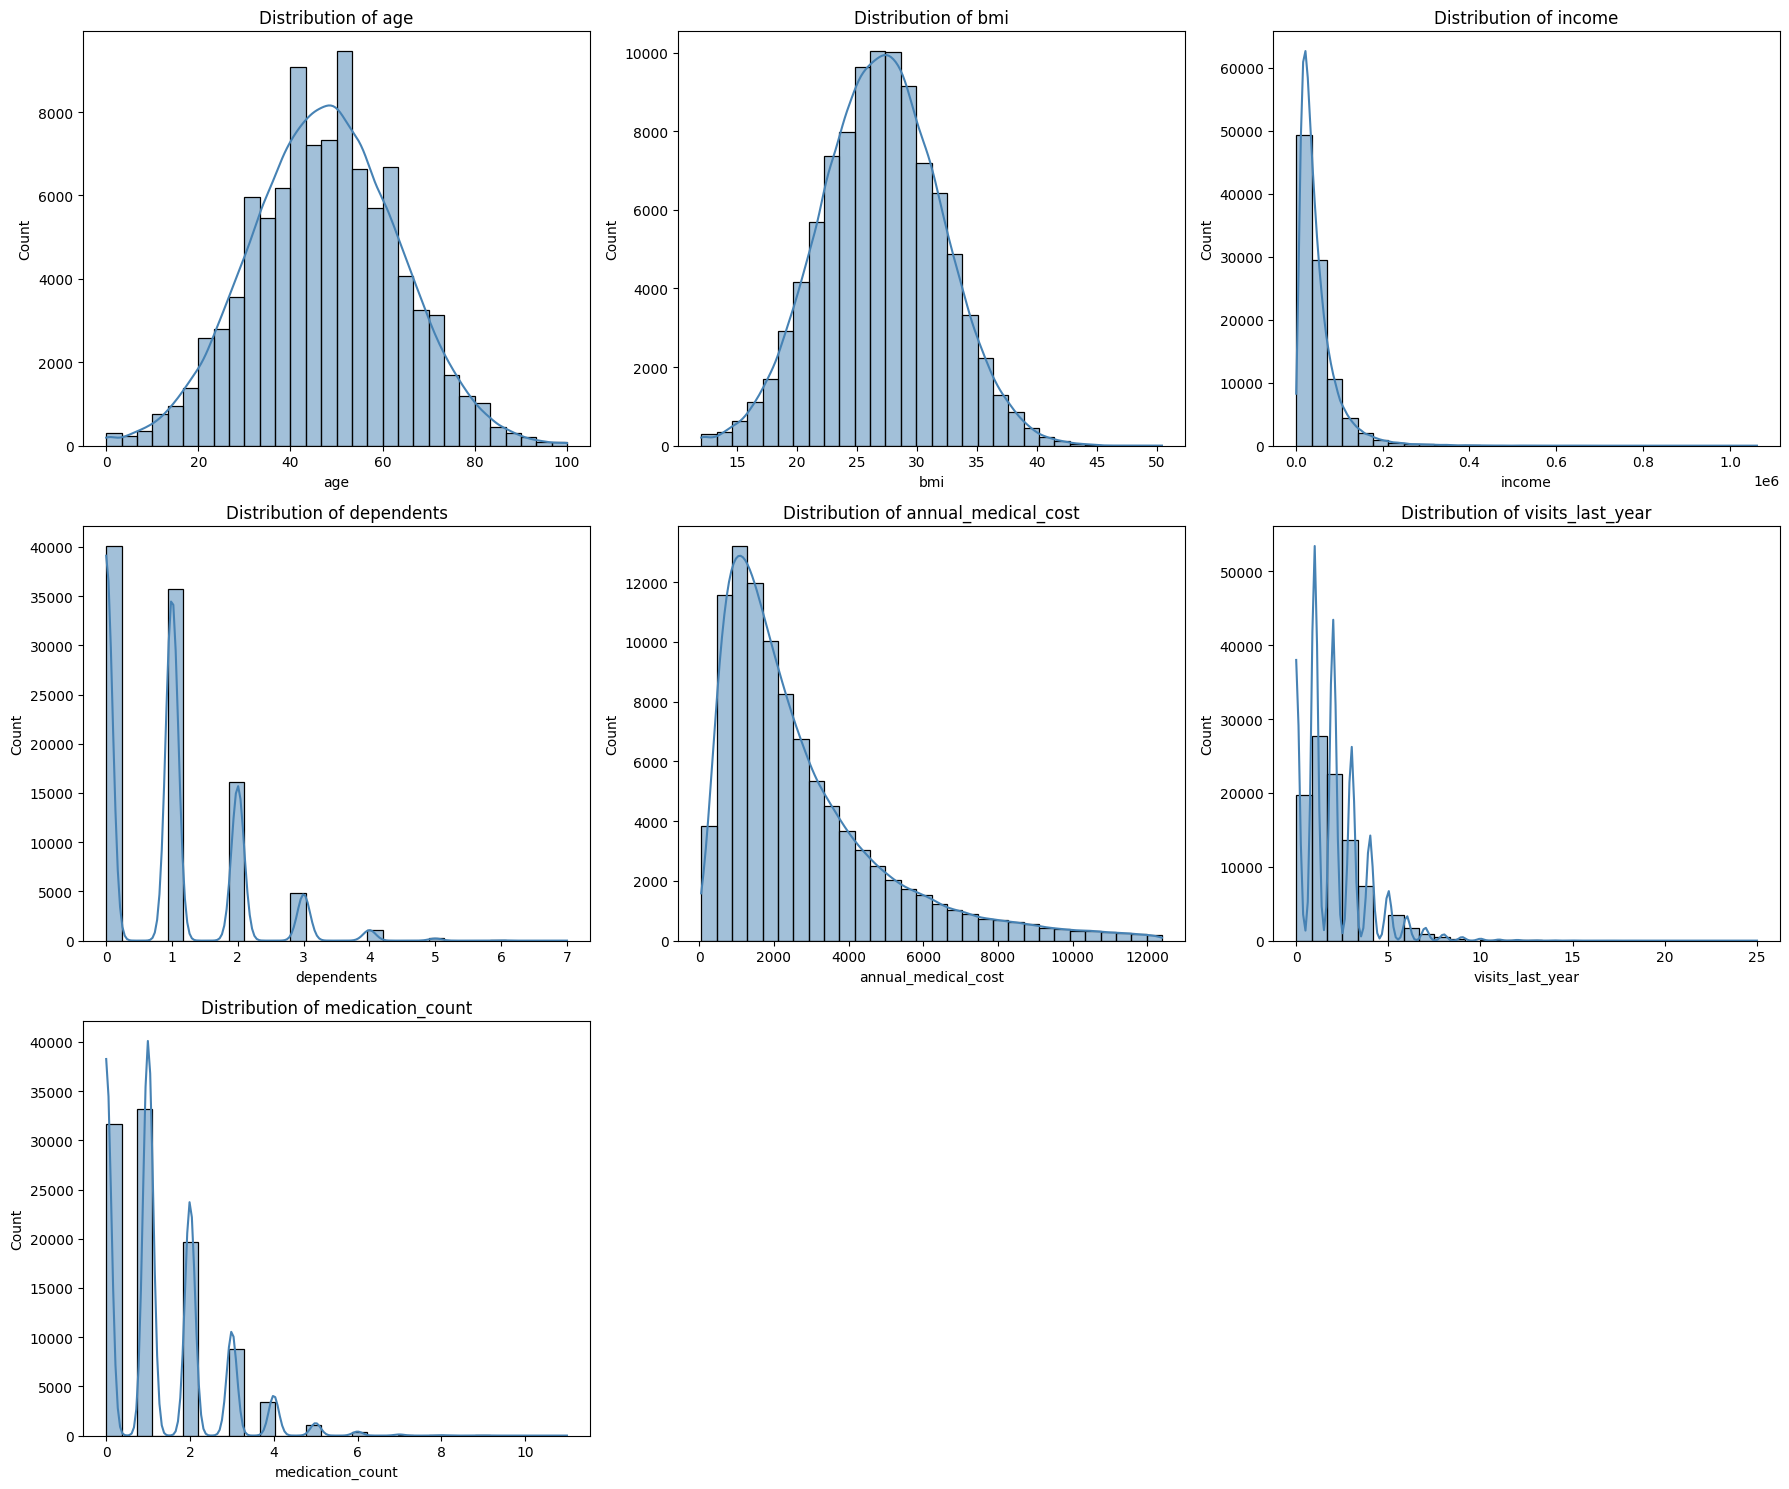

In [15]:
numeric_cols = ['age', 'bmi', 'income', 'dependents', 'annual_medical_cost',
                'visits_last_year', 'medication_count']
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=data_cleaned, x=col, kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution of {col}', fontsize=12)
plt.tight_layout()
plt.show()

## 5.2 Categorical Feature Distributions

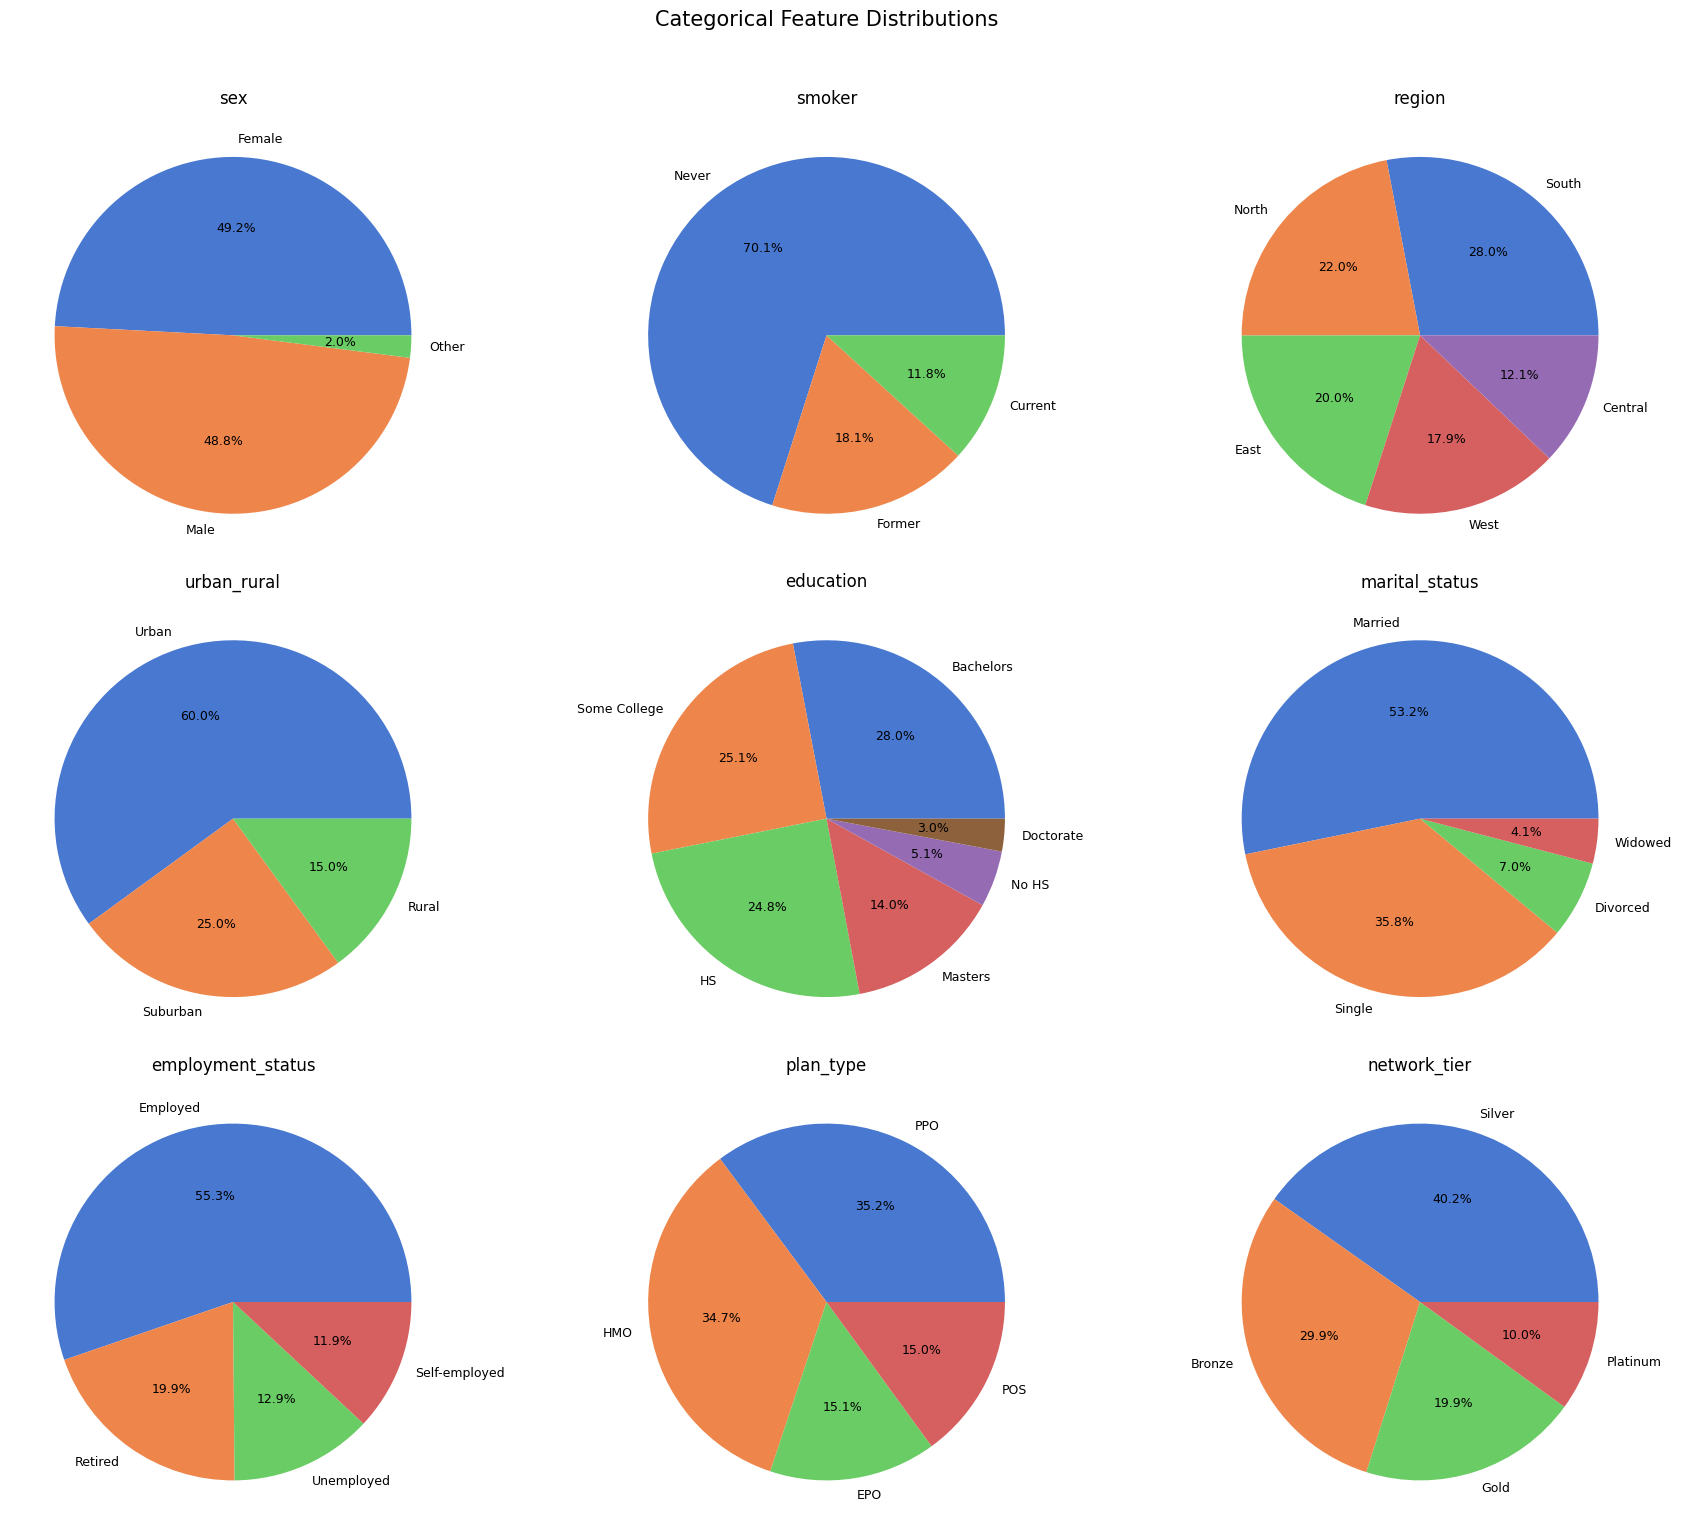

In [16]:
cat_cols = ['sex', 'smoker', 'region', 'urban_rural', 'education',
            'marital_status', 'employment_status', 'plan_type', 'network_tier']
n_cols_plot = 3
n_rows_plot = (len(cat_cols) + n_cols_plot - 1) // n_cols_plot

plt.figure(figsize=(18, 5 * n_rows_plot))
for i, col in enumerate(cat_cols):
    plt.subplot(n_rows_plot, n_cols_plot, i + 1)
    x = data_cleaned[col].value_counts().reset_index()
    plt.pie(x=x['count'], labels=x[col], autopct="%0.1f%%",
            colors=sns.color_palette('muted'), textprops={'fontsize': 9})
    plt.title(col, fontsize=12)
plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 5.3 Correlation Analysis (Top Features)

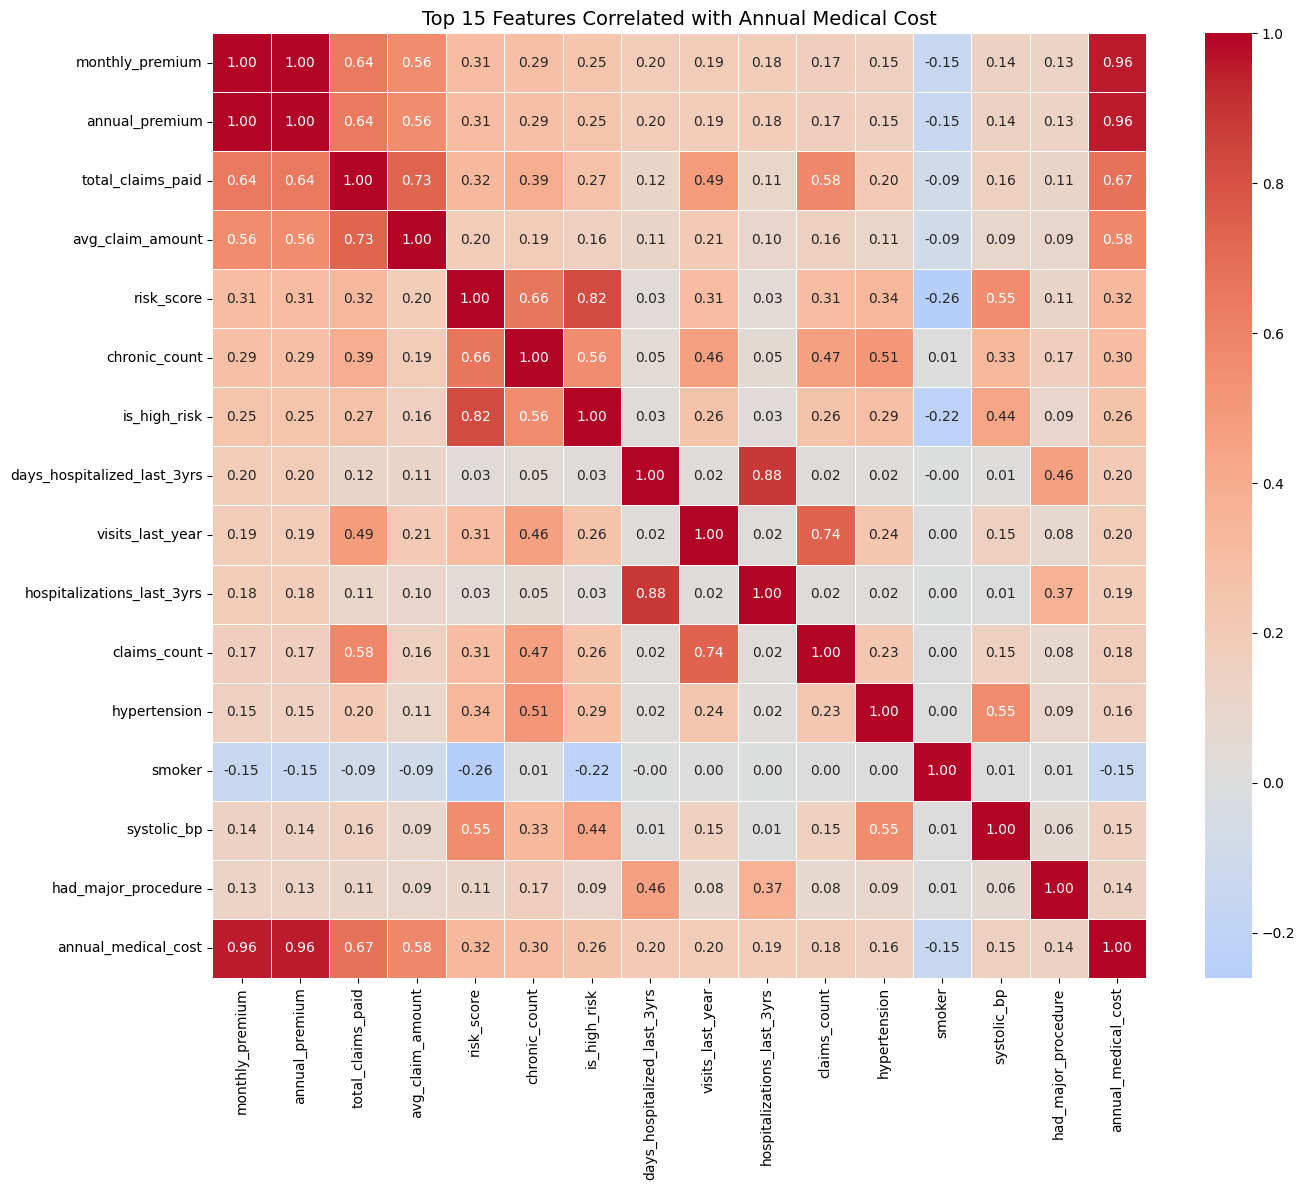


Top 15 correlations with annual_medical_cost:
monthly_premium                0.955407
annual_premium                 0.955407
total_claims_paid              0.673142
avg_claim_amount               0.581138
risk_score                     0.321318
chronic_count                  0.302445
is_high_risk                   0.264096
days_hospitalized_last_3yrs    0.204865
visits_last_year               0.196427
hospitalizations_last_3yrs     0.187738
claims_count                   0.176936
hypertension                   0.160740
smoker                         0.152277
systolic_bp                    0.151470
had_major_procedure            0.139307


In [17]:
# Encode categorical columns for correlation
data_corr = data_cleaned.copy()
label_encoder = LabelEncoder()
for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = label_encoder.fit_transform(data_corr[col])

corr_matrix = data_corr.corr()

# Show top 15 features most correlated with the target
target_corr = corr_matrix['annual_medical_cost'].drop('annual_medical_cost').abs().sort_values(ascending=False)
top_features = target_corr.head(15).index.tolist() + ['annual_medical_cost']

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix.loc[top_features, top_features], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, linecolor='white')
plt.title('Top 15 Features Correlated with Annual Medical Cost', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 15 correlations with annual_medical_cost:")
print(target_corr.head(15).to_string())

# 6. Feature Engineering & Encoding

In [18]:
# One-hot encode categorical features
dum = pd.get_dummies(data_cleaned.select_dtypes(include='object'), drop_first=True, dtype=int)
print(f"Encoded features shape: {dum.shape}")
dum.head()

Encoded features shape: (98124, 30)


,sex_Male,sex_Other,region_East,region_North,region_South,region_West,urban_rural_Suburban,urban_rural_Urban,education_Doctorate,education_HS,...,smoker_Never,alcohol_freq_Occasional,alcohol_freq_Unknown,alcohol_freq_Weekly,plan_type_HMO,plan_type_POS,plan_type_PPO,network_tier_Gold,network_tier_Platinum,network_tier_Silver
0,0,0,0,1,0,0,1,0,1,0,...,1,0,1,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,1,0,0,1,0,1,0,1,0,0
2,1,0,0,1,0,0,0,0,0,1,...,1,0,1,0,1,0,0,0,1,0
3,1,0,0,1,0,0,1,0,0,0,...,1,0,1,0,1,0,0,0,0,1
4,1,0,0,0,0,0,1,0,1,0,...,1,0,0,0,0,1,0,0,1,0


In [19]:
# Combine numeric and encoded features
data_model = pd.concat([data_cleaned.select_dtypes(exclude='object'), dum], axis=1)
print(f"Final feature matrix shape: {data_model.shape}")
data_model.head()

Final feature matrix shape: (98124, 73)


,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,smoker_Never,alcohol_freq_Occasional,alcohol_freq_Unknown,alcohol_freq_Weekly,plan_type_HMO,plan_type_POS,plan_type_PPO,network_tier_Gold,network_tier_Platinum,network_tier_Silver
0,52,22700.0,3,1,27.4,2,0,0,4,121.0,...,1,0,1,0,0,0,1,0,0,0
1,79,12800.0,3,1,26.6,2,0,0,3,131.0,...,1,0,0,1,0,1,0,1,0,0
2,68,40700.0,5,3,31.5,1,0,0,4,160.0,...,1,0,1,0,1,0,0,0,1,0
3,15,15600.0,5,3,31.6,0,0,0,1,104.0,...,1,0,1,0,1,0,0,0,0,1
4,53,89600.0,2,0,30.5,3,0,0,2,136.0,...,1,0,0,0,0,1,0,0,1,0


In [20]:
X = data_model.drop(columns=['annual_medical_cost'])
y = data_model['annual_medical_cost']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (98124, 72)
y shape: (98124,)


# 7. Model Training

## 7.1 GPU-Accelerated Imports

In [21]:
# GPU-accelerated models (for Colab/Kaggle with GPU runtime)
try:
    from cuml.ensemble import RandomForestRegressor as RFR
    print("Using cuML GPU-accelerated RandomForestRegressor")
except ImportError:
    from sklearn.ensemble import RandomForestRegressor as RFR
    print("cuML not available, using sklearn RandomForestRegressor (CPU)")

from xgboost import XGBRegressor
print("XGBRegressor ready (GPU via tree_method='hist', device='cuda')")

Using cuML GPU-accelerated RandomForestRegressor
XGBRegressor ready (GPU via tree_method='hist', device='cuda')


## 7.2 Data Splits: 70/30, 80/20, 90/10

In [22]:
splits = {
    '70/30': train_test_split(X, y, test_size=0.30, random_state=7),
    '80/20': train_test_split(X, y, test_size=0.20, random_state=7),
    '90/10': train_test_split(X, y, test_size=0.10, random_state=7),
}
for name, (X_tr, X_te, _, _) in splits.items():
    print(f"  {name}: train={X_tr.shape[0]:,}, test={X_te.shape[0]:,}")

  70/30: train=68,686, test=29,438
  80/20: train=78,499, test=19,625
  90/10: train=88,311, test=9,813


## 7.3 Hyperparameter Grids

In [23]:
# Linear Regression has no meaningful hyperparameters to loop —
# we iterate over fit_intercept to keep the pattern consistent.
lr_params = [
    {'fit_intercept': True},
    {'fit_intercept': False},
]

rfr_params = [
    {'n_estimators': 100, 'max_depth': 16, 'random_state': 7},
    {'n_estimators': 200, 'max_depth': 5,    'random_state': 7},
    {'n_estimators': 300, 'max_depth': 10,   'random_state': 7},
]

gbr_params = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'random_state': 7},
    {'n_estimators': 200, 'learning_rate': 0.10, 'max_depth': 4, 'random_state': 7},
    {'n_estimators': 300, 'learning_rate': 0.15, 'max_depth': 5, 'random_state': 7},
]

print('Parameter grids ready.')

Parameter grids ready.


## 7.4 Training Loop

In [26]:
best_results = {}

for split_name, (X_tr, X_te, y_tr, y_te) in splits.items():
    best_results[split_name] = {}
    print(f'\n{"="*50}')
    print(f'Split: {split_name}')
    print(f'{"="*50}')

    # -- Linear Regression --
    best_lr_score, best_lr = -1, None
    for p in lr_params:
        m = LinearRegression(**p).fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        sc = r2_score(y_te, y_pred)
        if sc > best_lr_score:
            best_lr_score, best_lr = sc, (m, p)
    m, p = best_lr
    y_pred_te = m.predict(X_te)
    y_pred_tr = m.predict(X_tr)
    best_results[split_name]['Linear Regression'] = {
        'train_r2': r2_score(y_tr, y_pred_tr),
        'test_r2':  best_lr_score,
        'test_mae': mean_absolute_error(y_te, y_pred_te),
        'test_rmse': mean_squared_error(y_te, y_pred_te),
        'params': p, 'model': m
    }
    print(f'  LR   R2={best_lr_score:.4f}  MAE={best_results[split_name]["Linear Regression"]["test_mae"]:.2f}  RMSE={best_results[split_name]["Linear Regression"]["test_rmse"]:.2f}')

    # -- Random Forest Regressor --
    best_rfr_score, best_rfr = -1, None
    for p in rfr_params:
        m = RFR(**p).fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        sc = r2_score(y_te, y_pred)
        if sc > best_rfr_score:
            best_rfr_score, best_rfr = sc, (m, p)
    m, p = best_rfr
    y_pred_te = m.predict(X_te)
    y_pred_tr = m.predict(X_tr)
    best_results[split_name]['Random Forest'] = {
        'train_r2': r2_score(y_tr, y_pred_tr),
        'test_r2':  best_rfr_score,
        'test_mae': mean_absolute_error(y_te, y_pred_te),
        'test_rmse': mean_squared_error(y_te, y_pred_te),
        'params': p, 'model': m
    }
    print(f'  RFR  R2={best_rfr_score:.4f}  MAE={best_results[split_name]["Random Forest"]["test_mae"]:.2f}  RMSE={best_results[split_name]["Random Forest"]["test_rmse"]:.2f}')

    # -- XGBoost Regressor --
    best_gbr_score, best_gbr = -1, None
    for p in gbr_params:
        m = XGBRegressor(tree_method="hist", device="cuda", **p).fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        sc = r2_score(y_te, y_pred)
        if sc > best_gbr_score:
            best_gbr_score, best_gbr = sc, (m, p)
    m, p = best_gbr
    y_pred_te = m.predict(X_te)
    y_pred_tr = m.predict(X_tr)
    best_results[split_name]['Gradient Boosting'] = {
        'train_r2': r2_score(y_tr, y_pred_tr),
        'test_r2':  best_gbr_score,
        'test_mae': mean_absolute_error(y_te, y_pred_te),
        'test_rmse': mean_squared_error(y_te, y_pred_te),
        'params': p, 'model': m
    }
    print(f'  GBR  R2={best_gbr_score:.4f}  MAE={best_results[split_name]["Gradient Boosting"]["test_mae"]:.2f}  RMSE={best_results[split_name]["Gradient Boosting"]["test_rmse"]:.2f}')

print('\nTraining complete.')


Split: 70/30
  LR   R2=0.9655  MAE=259.39  RMSE=171282.59
  RFR  R2=0.9978  MAE=29.49  RMSE=10736.66
  GBR  R2=0.9991  MAE=21.57  RMSE=4322.20

Split: 80/20
  LR   R2=0.9654  MAE=259.30  RMSE=172124.50
  RFR  R2=0.9978  MAE=29.96  RMSE=10991.14
  GBR  R2=0.9991  MAE=21.14  RMSE=4691.76

Split: 90/10
  LR   R2=0.9658  MAE=259.05  RMSE=173378.51
  RFR  R2=0.9979  MAE=30.12  RMSE=10568.51
  GBR  R2=0.9991  MAE=21.66  RMSE=4529.14

Training complete.


# 8. Results & Evaluation

## 8.1 Comparison Matrices

In [27]:
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
split_names = ['70/30', '80/20', '90/10']

# R-squared matrix
matrix_test = pd.DataFrame(index=model_names, columns=split_names, dtype=float)
matrix_train = pd.DataFrame(index=model_names, columns=split_names, dtype=float)
matrix_mae = pd.DataFrame(index=model_names, columns=split_names, dtype=float)
matrix_rmse = pd.DataFrame(index=model_names, columns=split_names, dtype=float)

for sp in split_names:
    for mn in model_names:
        r = best_results[sp][mn]
        matrix_test.loc[mn, sp] = round(r['test_r2'], 4)
        matrix_train.loc[mn, sp] = round(r['train_r2'], 4)
        matrix_mae.loc[mn, sp] = round(r['test_mae'], 2)
        matrix_rmse.loc[mn, sp] = round(r['test_rmse'], 2)

print('=== Test R-squared Matrix ===')
display(matrix_test)
print('\n=== Test MAE Matrix ===')
display(matrix_mae)
print('\n=== Test RMSE Matrix ===')
display(matrix_rmse)

=== Test R-squared Matrix ===


,70/30,80/20,90/10
Linear Regression,0.9655,0.9654,0.9658
Random Forest,0.9978,0.9978,0.9979
Gradient Boosting,0.9991,0.9991,0.9991



=== Test MAE Matrix ===


,70/30,80/20,90/10
Linear Regression,259.39,259.30,259.05
Random Forest,29.49,29.96,30.12
Gradient Boosting,21.57,21.14,21.66



=== Test RMSE Matrix ===


,70/30,80/20,90/10
Linear Regression,171282.59,172124.50,173378.51
Random Forest,10736.66,10991.14,10568.51
Gradient Boosting,4322.20,4691.76,4529.14


## 8.2 Heatmap Visualizations

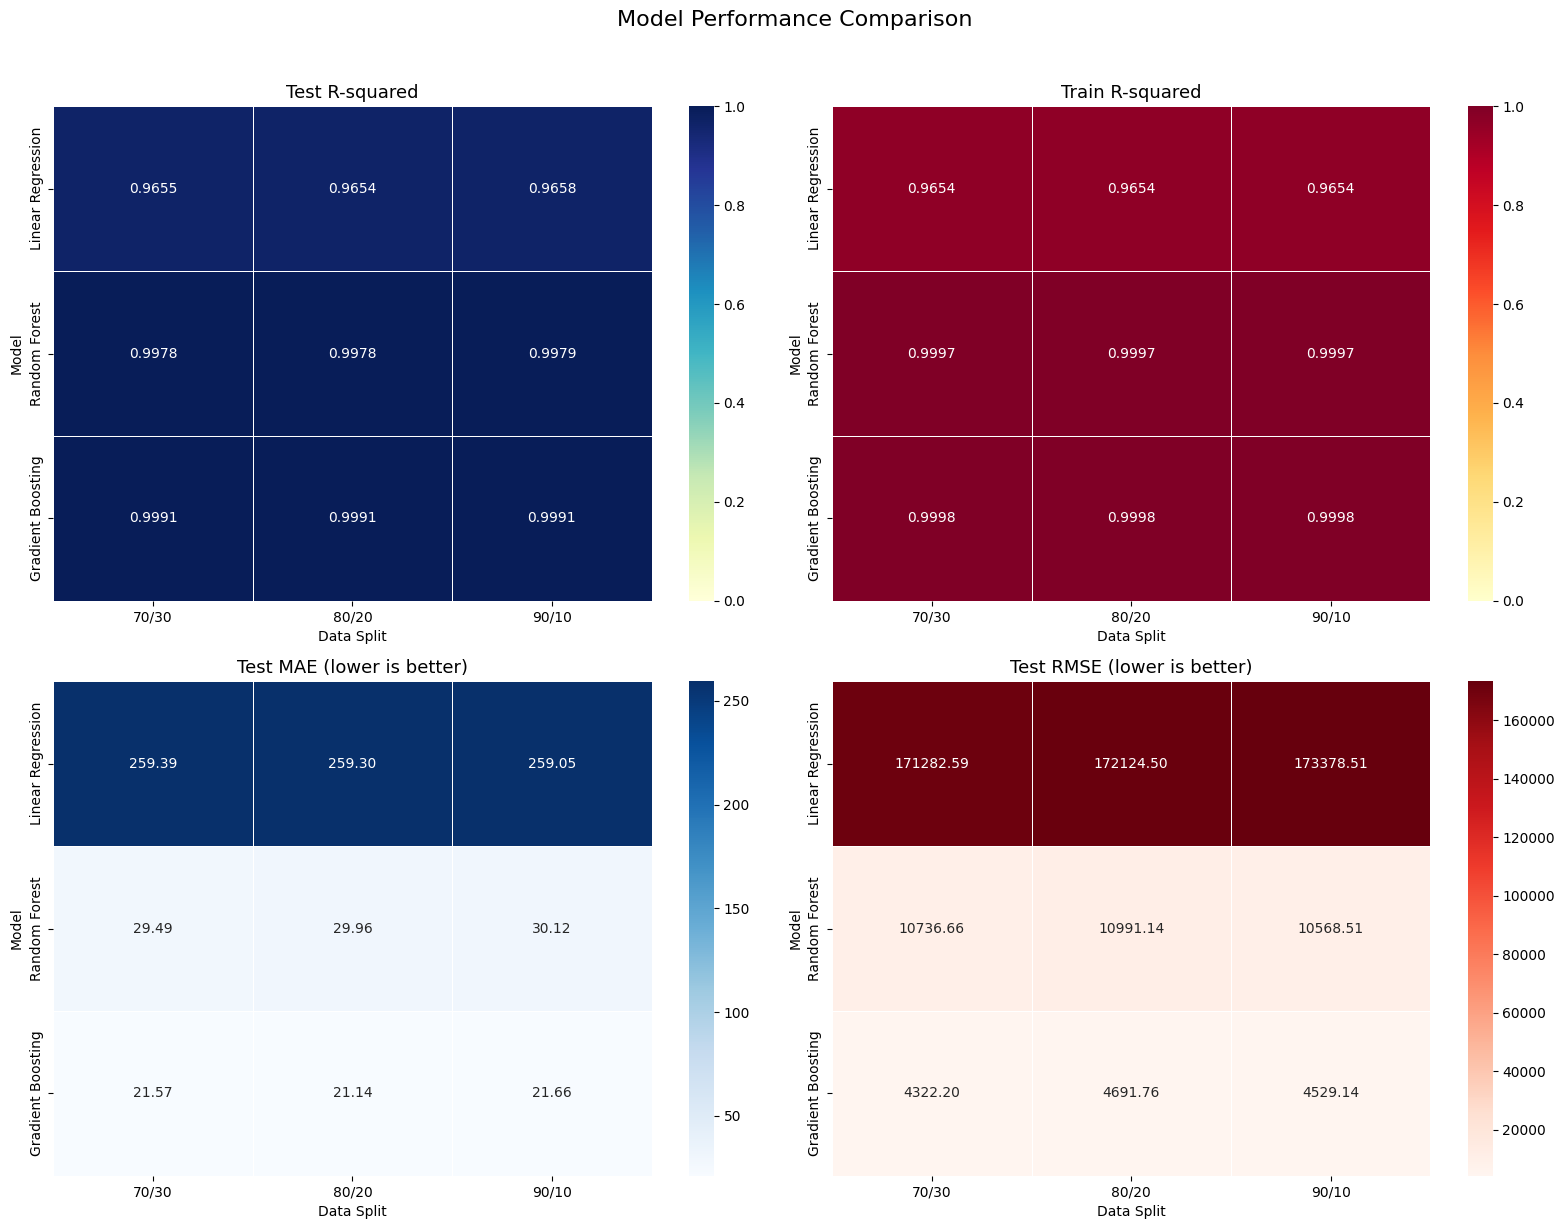

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(matrix_test.astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0, 0],
            linewidths=0.5, linecolor='white')
axes[0, 0].set_title('Test R-squared', fontsize=13)

sns.heatmap(matrix_train.astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', vmin=0, vmax=1, ax=axes[0, 1],
            linewidths=0.5, linecolor='white')
axes[0, 1].set_title('Train R-squared', fontsize=13)

sns.heatmap(matrix_mae.astype(float), annot=True, fmt='.2f',
            cmap='Blues', ax=axes[1, 0],
            linewidths=0.5, linecolor='white')
axes[1, 0].set_title('Test MAE (lower is better)', fontsize=13)

sns.heatmap(matrix_rmse.astype(float), annot=True, fmt='.2f',
            cmap='Reds', ax=axes[1, 1],
            linewidths=0.5, linecolor='white')
axes[1, 1].set_title('Test RMSE (lower is better)', fontsize=13)

for ax in axes.flat:
    ax.set_xlabel('Data Split')
    ax.set_ylabel('Model')

plt.suptitle('Model Performance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8.3 Full Results Summary

In [29]:
rows = []
for sp in split_names:
    for mn in model_names:
        r = best_results[sp][mn]
        rows.append({
            'Split': sp, 'Model': mn,
            'Best Params': str(r['params']),
            'Train R2': round(r['train_r2'], 4),
            'Test R2':  round(r['test_r2'],  4),
            'Test MAE': round(r['test_mae'], 2),
            'Test RMSE': round(r['test_rmse'], 2),
        })
summary_df = pd.DataFrame(rows)
summary_df

,Split,Model,Best Params,Train R2,Test R2,Test MAE,Test RMSE
0,70/30,Linear Regression,{'fit_intercept': False},0.9654,0.9655,259.39,171282.59
1,70/30,Random Forest,"{'n_estimators': 100, 'max_depth': 16, 'random...",0.9997,0.9978,29.49,10736.66
2,70/30,Gradient Boosting,"{'n_estimators': 300, 'learning_rate': 0.15, '...",0.9998,0.9991,21.57,4322.20
3,80/20,Linear Regression,{'fit_intercept': False},0.9654,0.9654,259.30,172124.50
4,80/20,Random Forest,"{'n_estimators': 100, 'max_depth': 16, 'random...",0.9997,0.9978,29.96,10991.14
5,80/20,Gradient Boosting,"{'n_estimators': 300, 'learning_rate': 0.15, '...",0.9998,0.9991,21.14,4691.76
6,90/10,Linear Regression,{'fit_intercept': False},0.9654,0.9658,259.05,173378.51
7,90/10,Random Forest,"{'n_estimators': 100, 'max_depth': 16, 'random...",0.9997,0.9979,30.12,10568.51
8,90/10,Gradient Boosting,"{'n_estimators': 300, 'learning_rate': 0.15, '...",0.9998,0.9991,21.66,4529.14


# 9. Model Diagnostics

## 9.1 Predicted vs Actual (Best Model per Split)

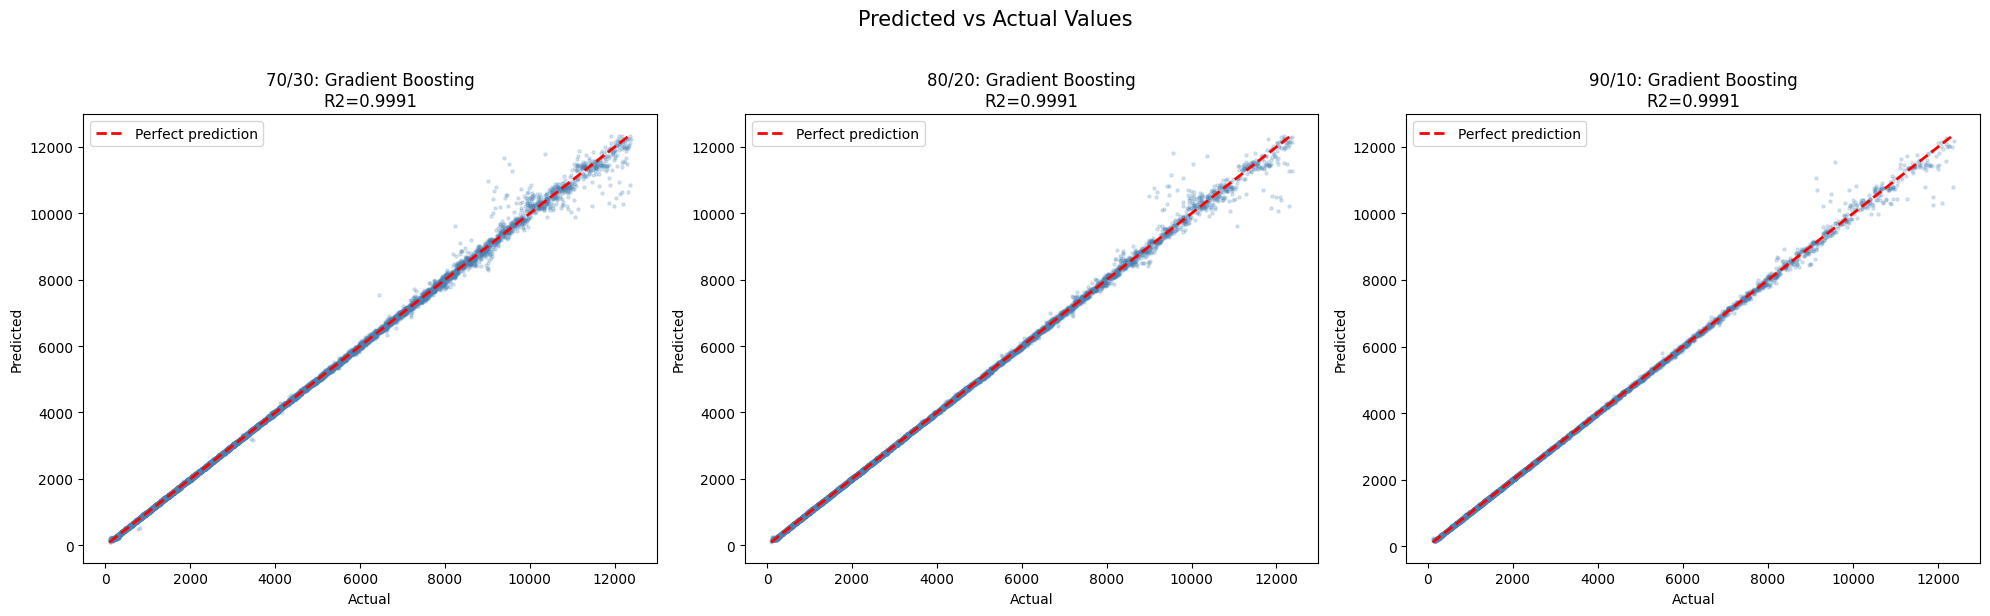

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, split_name in enumerate(split_names):
    models = best_results[split_name]
    best_model_name = max(models, key=lambda k: models[k]['test_r2'])
    best = models[best_model_name]
    X_tr, X_te, y_tr, y_te = splits[split_name]
    y_pred = best['model'].predict(X_te)

    axes[idx].scatter(y_te, y_pred, alpha=0.2, s=5, color='steelblue')
    min_val = min(y_te.min(), y_pred.min())
    max_val = max(y_te.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    axes[idx].set_title(f'{split_name}: {best_model_name}\nR2={best["test_r2"]:.4f}', fontsize=12)
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')
    axes[idx].legend()

plt.suptitle('Predicted vs Actual Values', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 9.2 Residual Analysis

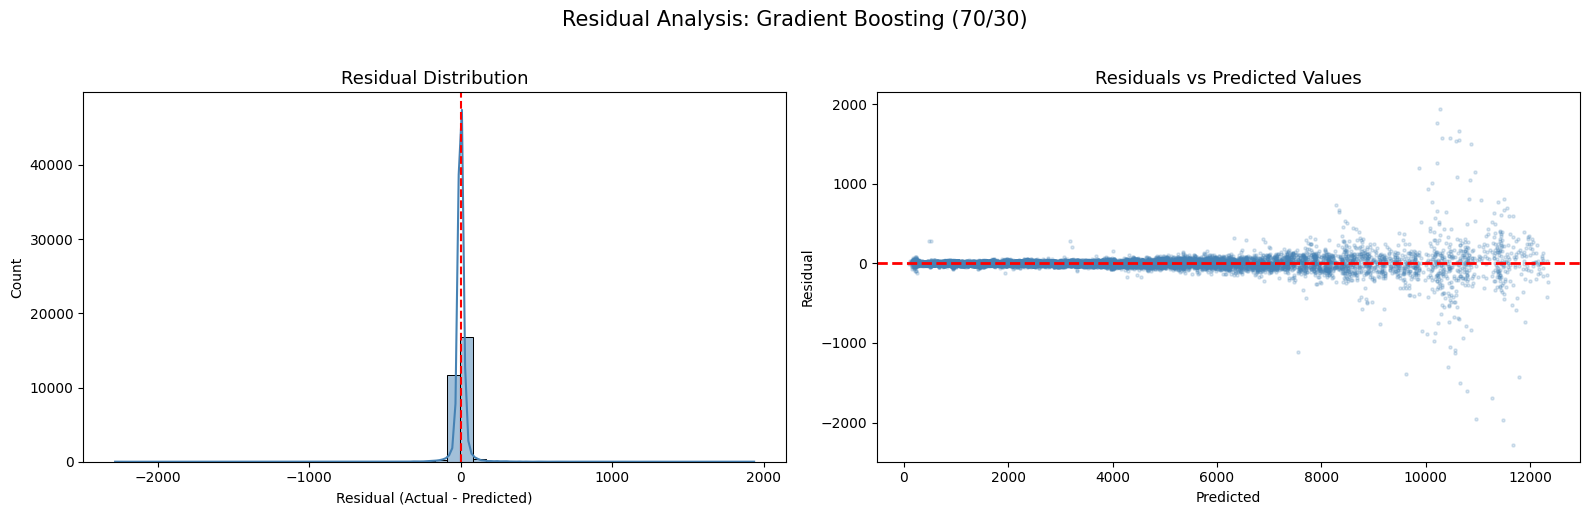

Mean residual:   0.0885
Std residual:    65.7445


In [31]:
# Use the best overall model for residual analysis
best_split = max(best_results, key=lambda s: max(m['test_r2'] for m in best_results[s].values()))
best_mn = max(best_results[best_split], key=lambda m: best_results[best_split][m]['test_r2'])
best_model_info = best_results[best_split][best_mn]

X_tr, X_te, y_tr, y_te = splits[best_split]
y_pred = best_model_info['model'].predict(X_te)
residuals = y_te - y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(residuals, kde=True, bins=50, color='steelblue', ax=axes[0])
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution', fontsize=13)
axes[0].set_xlabel('Residual (Actual - Predicted)')

axes[1].scatter(y_pred, residuals, alpha=0.2, s=5, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted Values', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.suptitle(f'Residual Analysis: {best_mn} ({best_split})', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():.4f}")
print(f"Std residual:    {residuals.std():.4f}")

## 9.3 Feature Importance

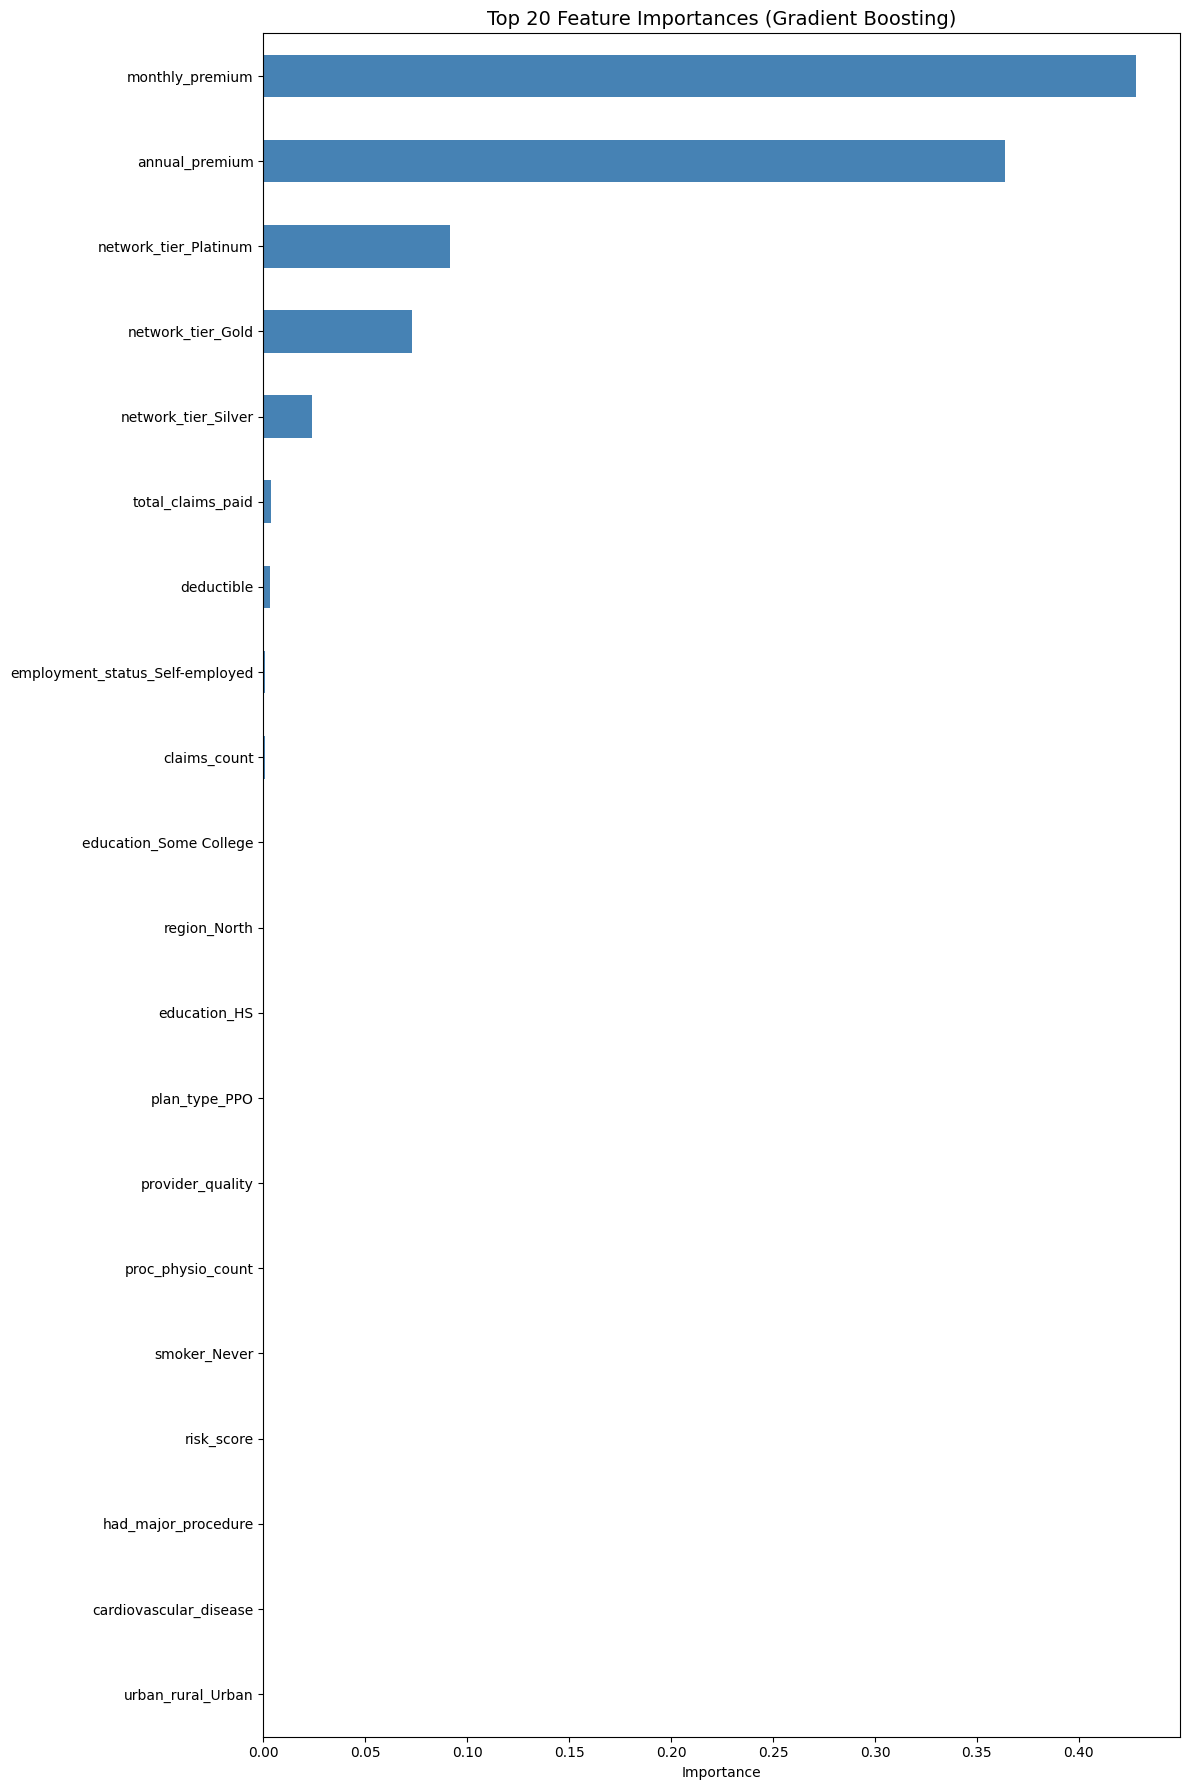


Top 10 most important features:
monthly_premium                    0.428198
annual_premium                     0.363889
network_tier_Platinum              0.091665
network_tier_Gold                  0.072743
network_tier_Silver                0.023692
total_claims_paid                  0.003625
deductible                         0.003229
employment_status_Self-employed    0.000808
claims_count                       0.000715
education_Some College             0.000601


In [32]:
# Feature importance from the best model (XGBoost or Random Forest)
if hasattr(best_model_info['model'], 'feature_importances_'):
    importances = best_model_info['model'].feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(12, max(8, len(feat_imp) * 0.25)))
    feat_imp.tail(20).plot(kind='barh', color='steelblue')
    plt.title(f'Top 20 Feature Importances ({best_mn})', fontsize=14)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 most important features:")
    print(feat_imp.sort_values(ascending=False).head(10).to_string())
else:
    print(f"{best_mn} does not provide feature importances.")

# 10. Save Best Model

In [33]:
# Identify and save the overall best model
best_split = max(best_results, key=lambda s: max(m['test_r2'] for m in best_results[s].values()))
best_mn = max(best_results[best_split], key=lambda m: best_results[best_split][m]['test_r2'])
best_model = best_results[best_split][best_mn]['model']
best_r2 = best_results[best_split][best_mn]['test_r2']

model_path = 'best_model.pkl'
joblib.dump(best_model, model_path)
print(f"Best model saved: {best_mn}")
print(f"  Split:    {best_split}")
print(f"  Test R2:  {best_r2:.4f}")
print(f"  Test MAE: {best_results[best_split][best_mn]['test_mae']:.2f}")
print(f"  Test RMSE:{best_results[best_split][best_mn]['test_rmse']:.2f}")
print(f"  Params:   {best_results[best_split][best_mn]['params']}")
print(f"  Saved to: {model_path}")

Best model saved: Gradient Boosting
  Split:    70/30
  Test R2:  0.9991
  Test MAE: 21.57
  Test RMSE:4322.20
  Params:   {'n_estimators': 300, 'learning_rate': 0.15, 'max_depth': 5, 'random_state': 7}
  Saved to: best_model.pkl
